In [1]:
# Import libraries
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.mask import mask
import xarray as xr
import rioxarray
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import os

**Import and read study area + buffer 10 km**

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\win10\AppData\Local\Temp\ipykernel_71448\616306709.py:2: SyntaxWarning: invalid escape sequence '\s'
  study_area_buff = gpd.read_file('vectores\study_area_buffer.geojson')


Text(7.348761650462018, 0.5, 'Latitud (°)')

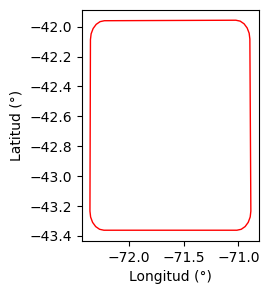

In [2]:
# Import and plot the study area with geopandas
study_area_buff = gpd.read_file('vectores\study_area_buffer.geojson')


fig, ax = plt.subplots(figsize=(3, 3))
study_area_buff.plot(ax=ax, color='none', edgecolor='red')
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')

In [3]:
# Get boundaries limits region analysis vector
minx, miny, maxx, maxy = study_area_buff.bounds.iloc[0, :]
print(minx, miny, maxx, maxy)

-72.35296441198041 -43.36359204235293 -70.88717735912768 -41.95679235399089


## August 2025 (No fire scenario)

**Read NO2 imported from GEE: median, std and n pixels**

In [3]:
# Read 2025 (No fire) NO2 data for study area
band_path01 = 'data_gee/NO2tropMed_0225_float_study_area.tif' # Median data
ds_path01 = xr.open_dataset(band_path01, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

band_path02 = 'data_gee/NO2tropStd_0225_float_study_area.tif'
ds_path02 = xr.open_dataset(band_path02, engine="rasterio", masked=True)

band_path03 = 'data_gee/NO2tropN_0225_float_study_area.tif'
ds_path03 = xr.open_dataset(band_path03, engine="rasterio", masked=True)

**Plot Raw data**

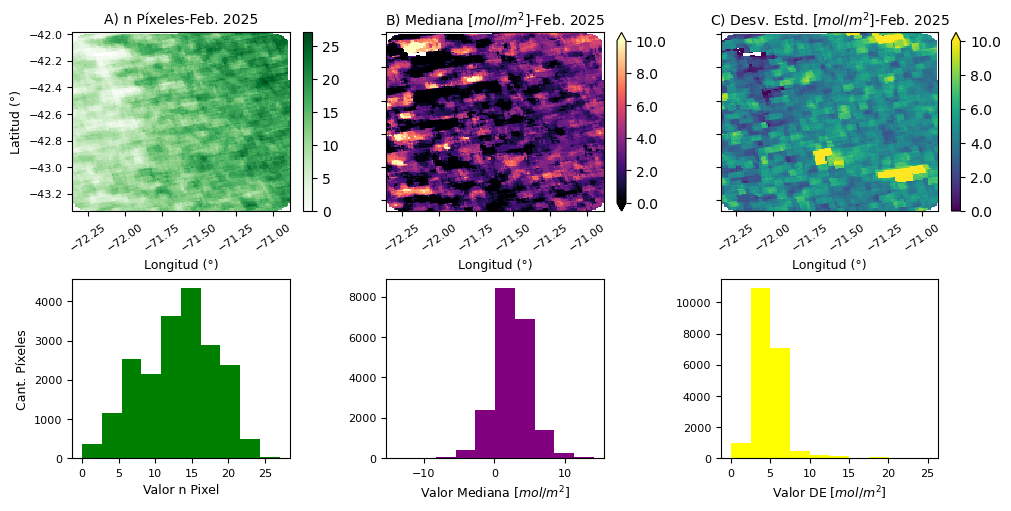

In [52]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5), constrained_layout=True)#, sharey=True)

ds_path03.band_data.plot(ax=ax[0, 0], vmin=0, cmap='Greens', cbar_kwargs={"label": None})
ax[0, 0].set_title('A) n Píxeles-Feb. 2025', fontsize=10)
ax[0, 0].set_ylabel('Latitud (°)', size=9)
ax[0, 0].set_xlabel('Longitud (°)', size=9)
ax[0, 0].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 0].tick_params(axis='y', labelsize=8)
ax[1, 0].hist(ds_path03.band_data.values.flatten(), color='green')
ax[1, 0].set_ylabel('Cant. Píxeles', size=9)
ax[1, 0].set_xlabel('Valor n Pixel', size=9)
ax[1, 0].tick_params(axis='both', labelsize=8)

ds_path01.band_data.plot(ax=ax[0, 1], vmin=0, vmax=10, cmap='magma', 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 1].set_title('B) Mediana [$mol/m^{2}$]-Feb. 2025', fontsize=10)
ax[0, 1].set_ylabel(None)
ax[0, 1].set_xlabel('Longitud (°)', size=9)
ax[0, 1].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 1].set_yticklabels([])
ax[1, 1].hist(ds_path01.band_data.values.flatten(), color='purple')
#ax[1, 0].set_ylabel('Cant. Píxeles', size=10)
ax[1, 1].set_xlabel('Valor Mediana [$mol/m^{2}$]', size=9)
ax[1, 1].tick_params(axis='both', labelsize=8)


ds_path02.band_data.plot(ax=ax[0, 2], vmin=0, vmax=10, cmap='viridis', 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 2].set_title('C) Desv. Estd. [$mol/m^{2}$]-Feb. 2025', fontsize=10)
ax[0, 2].set_ylabel(None)
ax[0, 2].set_xlabel('Longitud (°)', size=9)
ax[0, 2].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 2].set_yticklabels([])
ax[1, 2].hist(ds_path02.band_data.values.flatten(), color='yellow')
ax[1, 2].set_xlabel('Valor DE [$mol/m^{2}$]', size=9)
ax[1, 2].tick_params(axis='both', labelsize=8)

**--**

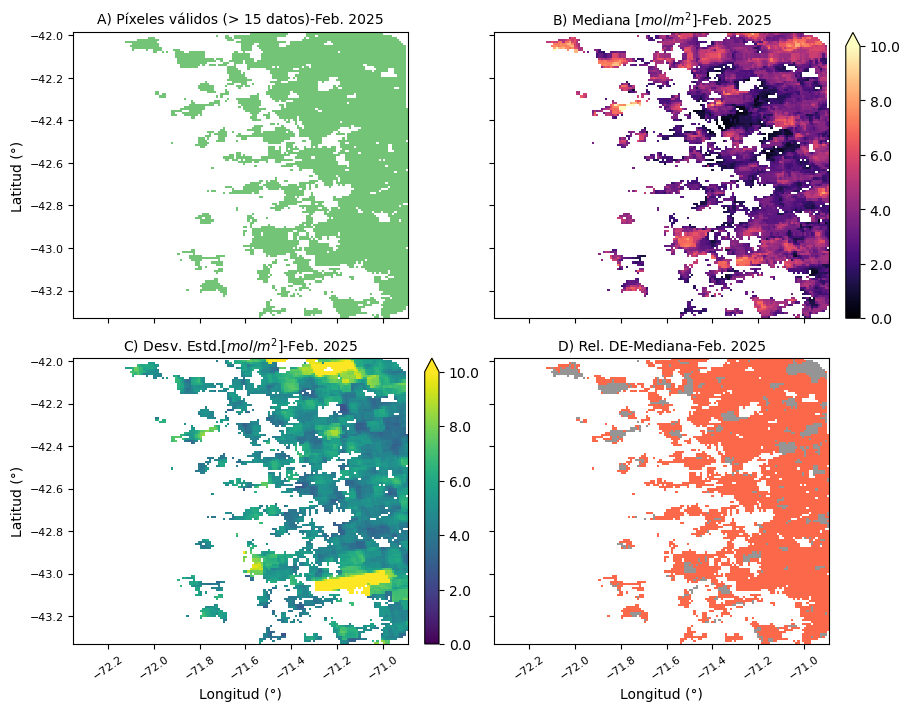

In [ ]:
# Set the figure and subplots
fig, ax = plt.subplots(2, 2, figsize=(9, 7), 
    sharey=True, sharex=True, 
    constrained_layout=True)

# Define a mask
mask_01 = (ds_path03.band_data > 15)  # n count pixels greater than 15 (from 30)
mask_0102 = (ds_path03.band_data > 15) & (ds_path01.band_data > 0)

## Pixels with > 15 valid data
n_val_01 = xr.where(mask_01, 1, 0).where(mask_01)
n_val_01.plot(ax=ax[0, 0], add_colorbar=False, cmap='Greens')
ax[0, 0].set_title('A) Píxeles válidos (> 15 datos)-Feb. 2025', fontsize=10)
ax[0, 0].set_ylabel('Latitud (°)', size=10)
ax[0, 0].set_xlabel(None)
#ax[0, 1].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 0].tick_params(axis='y', labelsize=8)

## Median values for valid pixels
med_val_01 = ds_path01.band_data.where(mask_0102)
med_val_01.plot(ax=ax[0, 1], cmap='magma', vmin=0, vmax=10, 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 1].set_title('B) Mediana [$mol/m^{2}$]-Feb. 2025', fontsize=10)
ax[0, 1].set_ylabel(None)
ax[0, 1].set_xlabel(None)

##-
std_val_01 = ds_path02.band_data.where(mask_0102)
std_val_01.plot(ax=ax[1, 0], cmap='viridis', vmin=0, vmax=10, 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[1, 0].set_title('C) Desv. Estd.[$mol/m^{2}$]-Feb. 2025', fontsize=10)
ax[1, 0].set_ylabel('Latitud (°)', size=10)
ax[1, 0].set_xlabel('Longitud (°)', size=10)
ax[1, 0].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[1, 0].tick_params(axis='y', labelsize=8)

##-
stdMed_val_01 = xr.where(std_val_01>med_val_01, 1, np.nan)
n_val_01.plot(ax=ax[1, 1], add_colorbar=False, cmap='Grays') # add background layer for pixels with std < median
stdMed_val_01.plot(ax=ax[1, 1], add_colorbar=False, cmap='Reds')
ax[1, 1].set_title('D) Rel. DE-Mediana-Feb. 2025', fontsize=10)
ax[1, 1].set_ylabel(None)
ax[1, 1].set_xlabel('Longitud (°)', size=10)
ax[1, 1].tick_params(axis='x', labelrotation=35, labelsize=8)

# NOTA
# mediana > sd ==> poca variabilidad
# mediana < sd ==> alta variabilidad

## January 2026 (Fire scenario)

**Read data downloaded from GEE**

In [30]:
# Read 2026 (fire) NO2 mean data for study area
band_path04 = 'data_gee/NO2tropMed_0126_float_study_area.tif' # Median data
ds_path04 = xr.open_dataset(band_path04, engine="rasterio", masked=True) # Setting masked=True converts NoData values automatically to NaN

band_path05 = 'data_gee/NO2tropStd_0126_float_study_area.tif'
ds_path05 = xr.open_dataset(band_path05, engine="rasterio", masked=True)

band_path06 = 'data_gee/NO2tropN_0126_float_study_area.tif'
ds_path06 = xr.open_dataset(band_path06, engine="rasterio", masked=True)

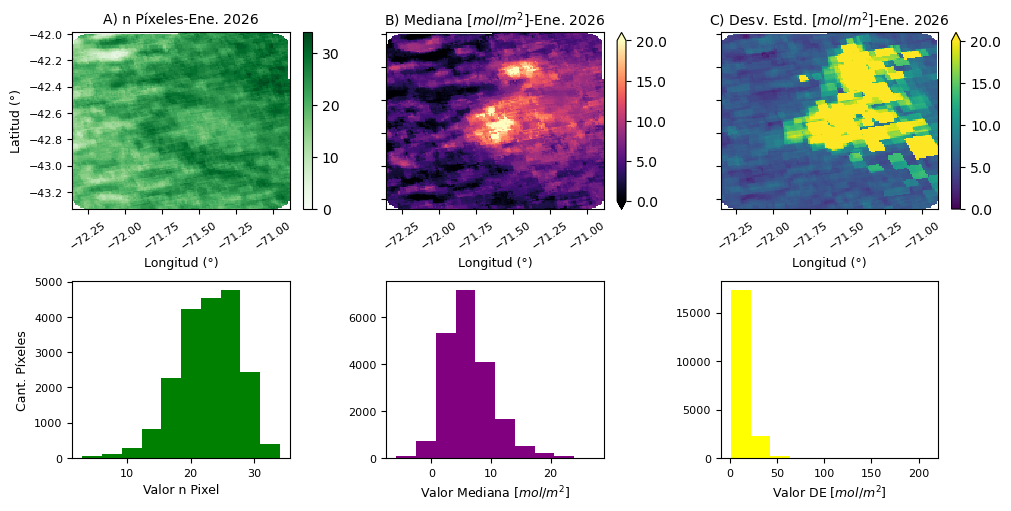

In [58]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5), constrained_layout=True)#, sharey=True)

ds_path06.band_data.plot(ax=ax[0, 0], vmin=0, cmap='Greens', cbar_kwargs={"label": None})
ax[0, 0].set_title('A) n Píxeles-Ene. 2026', fontsize=10)
ax[0, 0].set_ylabel('Latitud (°)', size=9)
ax[0, 0].set_xlabel('Longitud (°)', size=9)
ax[0, 0].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 0].tick_params(axis='y', labelsize=8)
ax[1, 0].hist(ds_path06.band_data.values.flatten(), color='green')
ax[1, 0].set_ylabel('Cant. Píxeles', size=9)
ax[1, 0].set_xlabel('Valor n Pixel', size=9)
ax[1, 0].tick_params(axis='both', labelsize=8)

ds_path04.band_data.plot(ax=ax[0, 1], vmin=0, vmax=20, cmap='magma', 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 1].set_title('B) Mediana [$mol/m^{2}$]-Ene. 2026', fontsize=10)
ax[0, 1].set_ylabel(None)
ax[0, 1].set_xlabel('Longitud (°)', size=9)
ax[0, 1].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 1].set_yticklabels([])
ax[1, 1].hist(ds_path04.band_data.values.flatten(), color='purple')
#ax[1, 0].set_ylabel('Cant. Píxeles', size=10)
ax[1, 1].set_xlabel('Valor Mediana [$mol/m^{2}$]', size=9)
ax[1, 1].tick_params(axis='both', labelsize=8)


ds_path05.band_data.plot(ax=ax[0, 2], vmin=0, vmax=20, cmap='viridis', 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 2].set_title('C) Desv. Estd. [$mol/m^{2}$]-Ene. 2026', fontsize=10)
ax[0, 2].set_ylabel(None)
ax[0, 2].set_xlabel('Longitud (°)', size=9)
ax[0, 2].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 2].set_yticklabels([])
ax[1, 2].hist(ds_path05.band_data.values.flatten(), color='yellow')
ax[1, 2].set_xlabel('Valor DE [$mol/m^{2}$]', size=9)
ax[1, 2].tick_params(axis='both', labelsize=8)

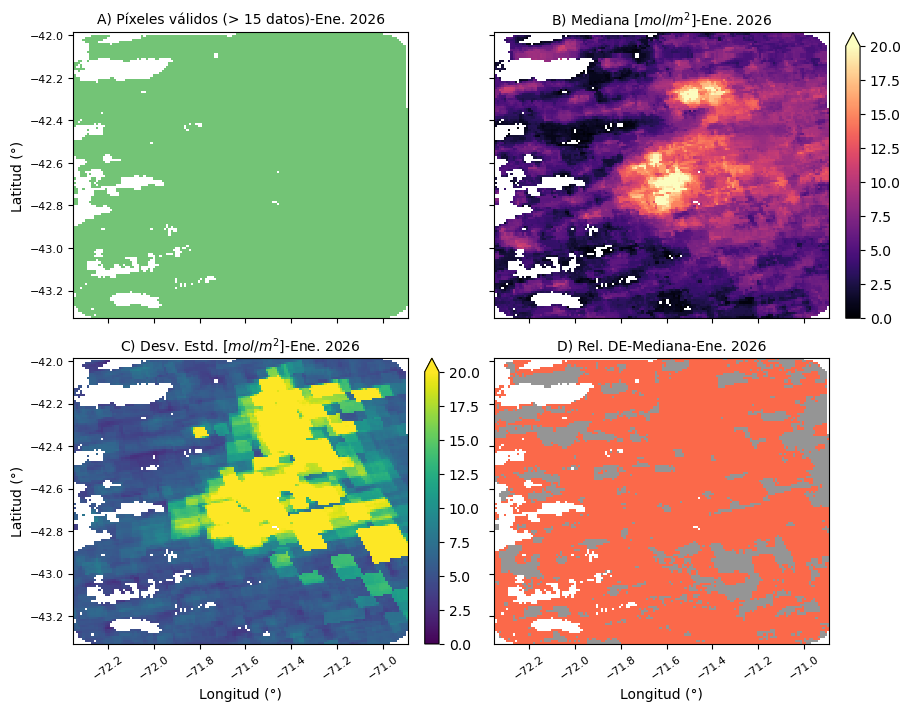

In [60]:
# Set the figure and subplots
fig, ax = plt.subplots(2, 2, figsize=(9, 7), 
    sharey=True, sharex=True, 
    constrained_layout=True)

# Define a mask
mask_02 = ds_path06.band_data > 15 # n count pixels greater than 15 (from 30)
mask_0202 = (ds_path06.band_data > 15) & (ds_path04.band_data > 0)

## Pixels with > 15 valid data
n_val_02 = xr.where(mask_02, 1, 0).where(mask_02)
n_val_02.plot(ax=ax[0, 0], add_colorbar=False, cmap='Greens')
ax[0, 0].set_title('A) Píxeles válidos (> 15 datos)-Ene. 2026', fontsize=10)
ax[0, 0].set_ylabel('Latitud (°)', size=10)
ax[0, 0].set_xlabel(None)
#ax[0, 1].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[0, 0].tick_params(axis='y', labelsize=8)

## Median values for valid pixels
med_val_02 = ds_path04.band_data.where(mask_0202)
med_val_02.plot(ax=ax[0, 1], cmap='magma', vmin=0, vmax=20, 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[0, 1].set_title('B) Mediana [$mol/m^{2}$]-Ene. 2026', fontsize=10)
ax[0, 1].set_ylabel(None)
ax[0, 1].set_xlabel(None)

##-
std_val_02 = ds_path05.band_data.where(mask_0202)
std_val_02.plot(ax=ax[1, 0], cmap='viridis', vmin=0, vmax=20, 
    cbar_kwargs={"label": None, "format": '%.1f'})
ax[1, 0].set_title('C) Desv. Estd. [$mol/m^{2}$]-Ene. 2026', fontsize=10)
ax[1, 0].set_ylabel('Latitud (°)', size=10)
ax[1, 0].set_xlabel('Longitud (°)', size=10)
ax[1, 0].tick_params(axis='x', labelrotation=35, labelsize=8)
ax[1, 0].tick_params(axis='y', labelsize=8)

##-
stdMed_val_02 = xr.where(std_val_02>med_val_02, 1, np.nan)
n_val_02.plot(ax=ax[1, 1], add_colorbar=False, cmap='Grays') # add background layer for pixels with std < median
stdMed_val_02.plot(ax=ax[1, 1], add_colorbar=False, cmap='Reds')
ax[1, 1].set_title('D) Rel. DE-Mediana-Ene. 2026', fontsize=10)
ax[1, 1].set_ylabel(None)
ax[1, 1].set_xlabel('Longitud (°)', size=10)
ax[1, 1].tick_params(axis='x', labelrotation=35, labelsize=8)

## Hotspots analysis

In [5]:
# Read hotspots data
hs_2025 = gpd.read_file(os.path.join('vectores', 'fires_modis_2025', 'fire_archive_M-C61_776775.shp'))
hs_2026 = gpd.read_file(os.path.join('vectores', 'fires_modis', 'fire_archive_M-C61_774972.shp'))

# Clip hs data
hs_2025 = hs_2025.clip(study_area_buff)
hs_2026 = hs_2026.clip(study_area_buff)

# Count hs
print('Total hs 2025:', hs_2025.shape[0])
print('Total hs 2026:', hs_2026.shape[0])


Total hs 2025: 130
Total hs 2026: 1532


## Aug 2025 vs Jan 2026 difference

C:\Users\win10\AppData\Local\Temp\ipykernel_65084\240015018.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxprops = ax.boxplot(cleaned_data, labels=['Feb. 2025', 'Ene. 2026'],


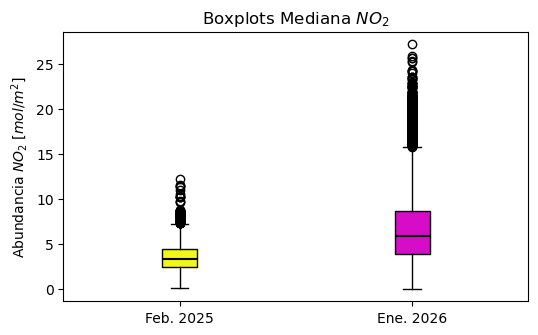

In [26]:
fig, ax = plt.subplots(figsize=(6, 3.5))

data_2025 = med_val_01.values.flatten()
data_2026 = med_val_02.values.flatten()

cleaned_data = [data_2025[~np.isnan(data_2025)], data_2026[~np.isnan(data_2026)]]

boxprops = ax.boxplot(cleaned_data, labels=['Feb. 2025', 'Ene. 2026'],
                      medianprops=dict(color='black', linewidth=1.5),
                      patch_artist=True)

# 3. Assign custom colors to the boxes
colors = ["#F3F707EF", "#D70CC7"]
for patch, color in zip(boxprops['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Abundancia $NO_{2}$ [$mol/m^{2}$]')
ax.set_xlabel(None)

plt.title('Boxplots Mediana $NO_{2}$')
plt.show()

In [20]:
# Perform Independent median T-Test (different variance)
t_stat, p_value = stats.ttest_ind(cleaned_data[0], cleaned_data[1], equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

T-statistic: -92.6335
P-value: 0.0000000000
